In [ ]:
# 英文名: Interpretable-Credit-Scoring-Card-Baseline
# 中文名: 基于逻辑回归与WOE分箱的可解释性信用评分卡模型
# 关键词: Interpretable (可解释性), Baseline (基线), WOE, Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# 基础路径
base_path = Path(r"C:\Users\田\Desktop\python实操\kaggle\Credit Card Approval Prediction")  # 你的原始路径

In [2]:
import toad
import scorecardpy as sc

In [3]:
application_record = pd.read_csv(base_path / 'application_record.csv')
credit_record = pd.read_csv(base_path / 'credit_record.csv')

In [4]:
application_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [5]:
credit_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


<big>toad<big>

In [6]:
# 1. 数据准备
df = application_record.merge(credit_record, on='ID', how='left').fillna(0)

In [7]:
df_clean = df[df['STATUS'] != 'X'].copy()

In [8]:
df_clean['STATUS'].value_counts()

STATUS
0    402100
C    329536
0    290654
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64

In [9]:
%%time
# 使用1-5，原因使用4-5，因类别极度不平衡，导致KS分数只有0.23，故使用1-5，适配冷启动等场景
df_clean['label'] = df_clean.groupby('ID')['STATUS'].transform(lambda x: x.astype(str).isin(['1','2','3','4','5']).any()).astype(int)
df_model  = df_clean.drop_duplicates('ID').drop(['ID', 'STATUS'], axis=1, errors='ignore')

CPU times: total: 1min 9s
Wall time: 1min 10s


In [10]:
df_model['label'].value_counts()

label
0    430872
1      4291
Name: count, dtype: int64

In [11]:
# 2. 特征筛选
import toad
X_sel, _ = toad.selection.select(df_model, target='label', empty=0.6, iv=0.02, corr=0.7, return_drop=True)
features = [c for c in X_sel.columns if c != 'label']
X, y = X_sel[features], X_sel['label']

In [12]:
# 3. 划分与分箱
from sklearn.model_selection import train_test_split

train, test = train_test_split(X_sel, test_size=0.3, stratify=y, random_state=42)
combiner = toad.Combiner().fit(train[features], train['label'], method='chi', min_samples=0.01, )
train_bin, test_bin = combiner.transform(train[features]), combiner.transform(test[features])
train_woe, test_woe = combiner.transform(train[features], method='woe'), combiner.transform(test[features], method='woe')

In [13]:
# 特征 PSI	
psi_series = toad.metrics.PSI(train_woe, test_woe)

In [14]:
psi_series

AMT_INCOME_TOTAL    0.000004
DAYS_BIRTH          0.000015
DAYS_EMPLOYED       0.000009
MONTHS_BALANCE      0.000015
dtype: float64

In [15]:
train['label'].value_counts()

label
0    301610
1      3004
Name: count, dtype: int64

In [16]:
(train_woe == np.inf).sum()

AMT_INCOME_TOTAL    0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
MONTHS_BALANCE      0
dtype: int64

In [17]:
(train_woe == -np.inf).sum()

AMT_INCOME_TOTAL    0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
MONTHS_BALANCE      0
dtype: int64

In [18]:
# 4. 建模
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=0.1, max_iter=1000,class_weight='balanced').fit(train_woe.replace([np.inf, -np.inf], 0), train['label'])

auc = toad.metrics.AUC(lr.predict_proba(test_woe)[:, 1], test['label'])
ks = toad.KS(lr.predict_proba(test_woe)[:, 1], test['label'])
print(f"模型评估 -> AUC: {auc:.4f}, KS: {ks:.4f}")

模型评估 -> AUC: 0.6762, KS: 0.3415


C:\anaconda\envs\py312\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)


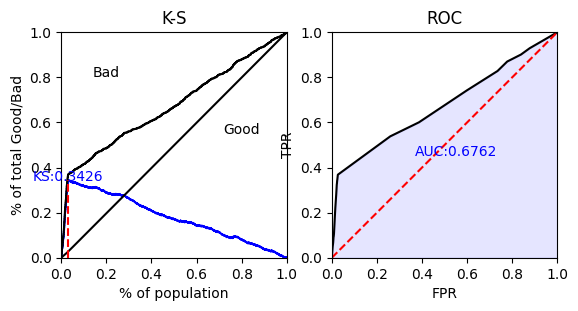

In [19]:
# 5. 绘制KS,ROC图
y_pred = lr.predict_proba(test_woe)[:, 1]
y_true = test['label']

stats_dict = sc.perf_eva(label=y_true, pred=y_pred, show_plot=True)

In [20]:
# 6. 保存模型与结果
print("\n" + "="*60)
print("9. 保存模型与结果")
print("="*60)

# os.makedirs('model', exist_ok=True)
# joblib.dump(lr, 'model/logistic_model.pkl')
# joblib.dump(transformer, 'model/woe_transformer.pkl')
# joblib.dump(combiner, 'model/bin_combiner.pkl')
print("模型组件已保存至 model/")


9. 保存模型与结果
模型组件已保存至 model/


<big>备注：toad内部toad.ScoreCard问题，导致生成评分卡和监控都有问题<big>

<big>scorecardpy<big>

In [31]:
import warnings
warnings.filterwarnings('ignore')

import scorecardpy as sc

# 1. 复制数据避免污染原数据
train_clean = train.copy()
test_clean = test.copy()

# 2. 数值型填 -1 (避免 NaN 导致 join 报错)，字符型填 'missing'
num_cols = train_clean.select_dtypes(include=[np.number]).columns.drop('label')
cat_cols = train_clean.select_dtypes(exclude=[np.number]).columns

train_clean[num_cols] = train_clean[num_cols].fillna(-1)
train_clean[cat_cols] = train_clean[cat_cols].fillna('missing').astype(str)

test_clean[num_cols] = test_clean[num_cols].fillna(-1)
test_clean[cat_cols] = test_clean[cat_cols].fillna('missing').astype(str)
# --------------------------------------------------


# 3. 变量筛选
# breaks_num: 数值型最大分箱数，默认为10，可适当增加以捕捉非线性
# fuzzify: 是否对类别进行模糊化处理，默认True
dt_var_filt = sc.var_filter(train_clean, y="label", 
                            iv_limit=0.02,        # 移除 IV < 0.02 的变量 (无预测力)
                            missing_limit=0.95,   # 移除缺失率 > 95% 的变量
                            identical_limit=0.95, # 移除几乎相同的变量
                            ) 

print(f"筛选后剩余变量数: {len(dt_var_filt.columns) - 1}") # -1 是因为包含 label

# 更新训练集和测试集
train_filt = train_clean[dt_var_filt.columns]
test_filt = test_clean[dt_var_filt.columns]




# 5. 生成评分卡 (使用清洗后的数据)
import scorecardpy as sc
from sklearn.linear_model import LogisticRegression

# A. 重新分箱与转换 (确保 bins 与 woe 格式严格匹配)
# 【修改点】使用 train_clean 而不是 train
bins = sc.woebin(train_filt, y='label' ,method='chi', min_samples=0.05, )
train_woe = sc.woebin_ply(train_filt, bins)
test_woe = sc.woebin_ply(test_filt, bins)

# B. 训练模型 (使用 scorecardpy 的 WOE 数据)
X_tr, y_tr = train_woe.drop('label', axis=1), train_clean['label']
lr_sc = LogisticRegression(C=0.1, max_iter=1000,class_weight='balanced').fit(X_tr.replace([np.inf, -np.inf], 0), y_tr)

# C. 生成评分卡规则表 (rate=2 对应 base_odds=2)
card_df = sc.scorecard(bins, lr_sc, X_tr, basepoints_eq0=600, odds0=2, pdo=20)

[INFO] filtering variables ...
筛选后剩余变量数: 3
[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [35]:
card_df

{'basepoints':      variable  bin  points
 0  basepoints  NaN       0,
 'DAYS_BIRTH':      variable                  bin  points
 1  DAYS_BIRTH      [-inf,-19500.0)   209.0
 2  DAYS_BIRTH  [-19500.0,-13500.0)   208.0
 3  DAYS_BIRTH       [-13500.0,inf)   204.0,
 'DAYS_EMPLOYED':         variable                bin  points
 4  DAYS_EMPLOYED     [-inf,-3800.0)   206.0
 5  DAYS_EMPLOYED  [-3800.0,-3200.0)   203.0
 6  DAYS_EMPLOYED  [-3200.0,-1800.0)   208.0
 7  DAYS_EMPLOYED  [-1800.0,-1200.0)   203.0
 8  DAYS_EMPLOYED   [-1200.0,-400.0)   205.0
 9  DAYS_EMPLOYED       [-400.0,inf)   210.0,
 'AMT_INCOME_TOTAL':             variable                  bin  points
 10  AMT_INCOME_TOTAL      [-inf,120000.0)   208.0
 11  AMT_INCOME_TOTAL  [120000.0,150000.0)   205.0
 12  AMT_INCOME_TOTAL  [150000.0,200000.0)   212.0
 13  AMT_INCOME_TOTAL       [200000.0,inf)   204.0}

In [103]:
# 6. 打分与评估
# 1. 应用评分卡进行打分 (返回包含明细和总分的 DataFrame)
scores_train = sc.scorecard_ply(dt=train_clean, card=card_df, only_total_score=False)
scores_test = sc.scorecard_ply(dt=test_clean, card=card_df, only_total_score=False)

# 2. 提取总分列
train_scores = scores_train['score']
test_scores = scores_test['score']

# 3. 评估 PSI
psi = toad.metrics.PSI(train_scores, test_scores)

print(f"\n✅ 打分完成:")
print(f"   训练集平均分: {train_scores.mean():.1f}")
print(f"   测试集平均分: {test_scores.mean():.1f}")
print(f"   PSI: {psi:.4f}")


✅ 打分完成:
   训练集平均分: 620.6
   测试集平均分: 620.6
   PSI: 0.0002
